
 Problem 1: Class Activation Map (CAM)
1a. GAP outputs: [2.5, 0.5, 1.0]
1b. Class score: 5.5
1c. CAM:
[4, 4]
[5, 9]

1d. Normalized CAM:
[0.0, 0.0]
[0.2, 1.0]

1e. Bilinear 5x5 upsampled CAM:
[0.0, 0.0, 0.0, 0.0, 0.0]
[0.05, 0.1, 0.15, 0.2, 0.25]
[0.1, 0.2, 0.3, 0.4, 0.5]
[0.15, 0.3, 0.45, 0.6, 0.75]
[0.2, 0.4, 0.6, 0.8, 1.0]

Mapping explanation: each 2x2 CAM cell corresponds to a rough 2.5x2.5 region of the 5x5 image, then interpolation produces the final overlay.

 Problem 2: CAM for Three Custom Sets

Set 1
GAP: [2.0, 1.0, 1.5]
Score: 6.5
CAM:
[9.5, 8.5]
[2.5, 5.5]

Normalized CAM:
[1.0, 0.857]
[0.0, 0.429]


Set 2
GAP: [2.0, 1.5, 1.5]
Score: 4.75
CAM:
[3.5, 4.0]
[6.0, 5.5]

Normalized CAM:
[0.0, 0.2]
[1.0, 0.8]


Set 3
GAP: [1.75, 1.5, 2.0]
Score: 5.875
CAM:
[6.0, 5.5]
[5.5, 6.5]

Normalized CAM:
[0.5, 0.0]
[0.0, 1.0]


 Problem 3: Grad-CAM for the Given Network
Grad-CAM alphas: [2, -1, 1]
Grad-CAM before ReLU:
[4, 4]
[5, 9]

Grad-CAM after ReLU:
[4, 4]
[5, 9]

Normalized Grad-CA

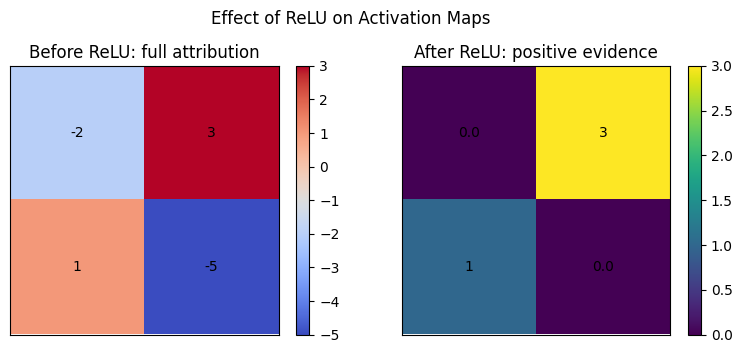

In [2]:
"""Assignment 7 mathematical solutions.

This script solves the CAM, Grad-CAM, ReLU/full-attribution, Integrated
Gradients, and comparison questions from the assignment PDF.  It intentionally
uses only the Python standard library so it can run even when NumPy, SciPy,
PyTorch, Captum, or Matplotlib are not installed.
"""

from __future__ import annotations


PI = 3.141592653589793


def print_header(title: str) -> None:
    print("\n" + "=" * 72)
    print(f" {title}")
    print("=" * 72)


def mean2(matrix: list[list[float]]) -> float:
    values = [value for row in matrix for value in row]
    return sum(values) / len(values)


def weighted_sum_maps(
    weights: list[float], feature_maps: list[list[list[float]]]
) -> list[list[float]]:
    rows = len(feature_maps[0])
    cols = len(feature_maps[0][0])
    return [
        [
            sum(weights[k] * feature_maps[k][i][j] for k in range(len(weights)))
            for j in range(cols)
        ]
        for i in range(rows)
    ]


def relu(matrix: list[list[float]]) -> list[list[float]]:
    return [[max(0.0, value) for value in row] for row in matrix]


def normalize(matrix: list[list[float]]) -> list[list[float]]:
    values = [value for row in matrix for value in row]
    min_value = min(values)
    max_value = max(values)
    if max_value == min_value:
        return [[0.0 for _ in row] for row in matrix]
    return [
        [(value - min_value) / (max_value - min_value) for value in row]
        for row in matrix
    ]


def matrix_round(matrix: list[list[float]], digits: int = 3) -> list[list[float]]:
    return [[round(value, digits) for value in row] for row in matrix]


def print_matrix(label: str, matrix: list[list[float]], digits: int = 3) -> None:
    print(label)
    for row in matrix:
        print([round(value, digits) for value in row])
    print()


def interpolate_2x2_to_5x5(matrix: list[list[float]]) -> list[list[float]]:
    """Bilinearly resize a 2x2 matrix to 5x5 for CAM visualization."""
    out: list[list[float]] = []
    for i in range(5):
        y = i / 4
        row = []
        for j in range(5):
            x = j / 4
            top = matrix[0][0] * (1 - x) + matrix[0][1] * x
            bottom = matrix[1][0] * (1 - x) + matrix[1][1] * x
            row.append(top * (1 - y) + bottom * y)
        out.append(row)
    return out


def dot(a: list[float], b: list[float]) -> float:
    return sum(x * y for x, y in zip(a, b))


def exp_taylor(x: float, terms: int = 24) -> float:
    total = 1.0
    term = 1.0
    for n in range(1, terms):
        term *= x / n
        total += term
    return total


def cos_taylor(x: float, terms: int = 18) -> float:
    total = 1.0
    term = 1.0
    sign = -1
    for n in range(1, terms):
        term *= x * x / ((2 * n - 1) * (2 * n))
        total += sign * term
        sign *= -1
    return total


def mat_vec_mul(matrix: list[list[float]], vector: list[float]) -> list[float]:
    return [dot(row, vector) for row in matrix]


def integrated_gradients(
    grad_fn,
    x: list[float],
    baseline: list[float],
    steps: int,
    verbose: bool = True,
) -> list[float]:
    diff = [x[i] - baseline[i] for i in range(len(x))]
    total_grad = [0.0 for _ in x]

    if verbose:
        print("k | alpha | point | gradient")
        print("--|-------|-------|---------")

    for k in range(1, steps + 1):
        alpha = k / steps
        point = [baseline[i] + alpha * diff[i] for i in range(len(x))]
        grad = grad_fn(point)
        total_grad = [total_grad[i] + grad[i] for i in range(len(x))]
        if verbose:
            print(
                f"{k:2d}| {alpha:5.3f} | "
                f"{[round(v, 3) for v in point]} | "
                f"{[round(v, 3) for v in grad]}"
            )

    avg_grad = [value / steps for value in total_grad]
    return [diff[i] * avg_grad[i] for i in range(len(x))]


def maybe_plot_relu_heatmaps(before: list[list[float]], after: list[list[float]]) -> None:
    try:
        import matplotlib.pyplot as plt
    except Exception as exc:
        print(f"Matplotlib is not available, so no image file was written: {exc}")
        print_matrix("Before ReLU:", before)
        print_matrix("After ReLU:", after)
        return

    fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
    fig.suptitle("Effect of ReLU on Activation Maps")

    for ax, matrix, title, cmap in [
        (axes[0], before, "Before ReLU: full attribution", "coolwarm"),
        (axes[1], after, "After ReLU: positive evidence", "viridis"),
    ]:
        im = ax.imshow(matrix, cmap=cmap)
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])
        for i, row in enumerate(matrix):
            for j, value in enumerate(row):
                ax.text(j, i, str(value), ha="center", va="center", color="black")
        fig.colorbar(im, ax=ax, fraction=0.046)

    plt.tight_layout()
    plt.savefig("problem_5_6_relu_effect.png", dpi=150)
    print("problem_5_6_relu_effect.png")


def main() -> None:
    print_header("Problem 1: Class Activation Map (CAM)")

    image = [
        [1, 2, 3, 2, 1],
        [0, 1, 2, 1, 0],
        [1, 3, 4, 3, 1],
        [0, 1, 2, 1, 0],
        [1, 2, 3, 2, 1],
    ]
    f1 = [[1, 2], [3, 4]]
    f2 = [[0, 1], [1, 0]]
    f3 = [[2, 1], [0, 1]]
    feature_maps = [f1, f2, f3]
    weights = [2, -1, 1]

    gap = [mean2(feature_map) for feature_map in feature_maps]
    score = dot(weights, gap)
    cam = weighted_sum_maps(weights, feature_maps)
    cam_norm = normalize(cam)
    cam_5x5 = interpolate_2x2_to_5x5(cam_norm)

    print("1a. GAP outputs:", [round(value, 3) for value in gap])
    print("1b. Class score:", round(score, 3))
    print_matrix("1c. CAM:", cam)
    print_matrix("1d. Normalized CAM:", cam_norm)
    print_matrix("1e. Bilinear 5x5 upsampled CAM:", cam_5x5, digits=2)
    print(
        "Mapping explanation: each 2x2 CAM cell corresponds to a rough 2.5x2.5 "
        "region of the 5x5 image, then interpolation produces the final overlay."
    )

    print_header("Problem 2: CAM for Three Custom Sets")

    custom_cam_sets = [
        (
            "Set 1",
            [[[2, 3], [1, 2]], [[1, 0], [2, 1]], [[3, 2], [0, 1]]],
            [1.5, 0.5, 2],
        ),
        (
            "Set 2",
            [[[1, 2], [3, 2]], [[2, 1], [1, 2]], [[1, 2], [2, 1]]],
            [2, 1, -0.5],
        ),
        (
            "Set 3",
            [[[2, 1], [1, 3]], [[1, 2], [2, 1]], [[3, 1], [1, 3]]],
            [0.5, 2, 1],
        ),
    ]

    for name, maps, custom_weights in custom_cam_sets:
        custom_gap = [mean2(feature_map) for feature_map in maps]
        custom_score = dot(custom_weights, custom_gap)
        custom_cam = weighted_sum_maps(custom_weights, maps)
        print(f"\n{name}")
        print("GAP:", [round(value, 3) for value in custom_gap])
        print("Score:", round(custom_score, 3))
        print_matrix("CAM:", custom_cam)
        print_matrix("Normalized CAM:", normalize(custom_cam))

    print_header("Problem 3: Grad-CAM for the Given Network")

    # For a GAP + one-FC-layer model, the Grad-CAM channel weights match the
    # class weights under this assignment's convention.
    alphas = weights
    grad_cam = weighted_sum_maps(alphas, feature_maps)
    grad_cam_relu = relu(grad_cam)
    print("Grad-CAM alphas:", alphas)
    print_matrix("Grad-CAM before ReLU:", grad_cam)
    print_matrix("Grad-CAM after ReLU:", grad_cam_relu)
    print_matrix("Normalized Grad-CAM:", normalize(grad_cam_relu))
    print("Conclusion: here Grad-CAM is equivalent to CAM.")

    print_header("Problem 4: Grad-CAM with Multiple FC Layers")

    pooled_features = [2.5, 0.5, 1.0]
    w1 = [
        [0.5, 1.0, 0.2],
        [1.0, -0.5, 1.0],
        [0.2, 1.0, 0.5],
        [1.0, 0.0, 0.3],
        [0.0, 1.0, -0.2],
    ]
    w2_class0 = [1.0, 0.5, -0.2, 1.0, 0.1]

    z1 = mat_vec_mul(w1, pooled_features)
    h1 = [max(0.0, value) for value in z1]
    score0 = dot(w2_class0, h1)
    relu_prime = [1.0 if value > 0 else 0.0 for value in z1]
    grad_features = [
        sum(w2_class0[j] * relu_prime[j] * w1[j][i] for j in range(len(w1)))
        for i in range(len(pooled_features))
    ]
    multi_fc_map = relu(weighted_sum_maps(grad_features, feature_maps))

    print("z1:", [round(value, 3) for value in z1])
    print("h1:", [round(value, 3) for value in h1])
    print("S0:", round(score0, 3))
    print("Grad-CAM alphas dS0/dF:", [round(value, 3) for value in grad_features])
    print_matrix("Grad-CAM map after ReLU:", multi_fc_map)
    print_matrix("Normalized map:", normalize(multi_fc_map))

    print_header("Problems 5 and 6: ReLU vs Full Attribution")

    sample_map = [[-2, 3], [1, -5]]
    sample_map_relu = relu(sample_map)
    maybe_plot_relu_heatmaps(sample_map, sample_map_relu)
    print(
        "Without ReLU, negative values remain and show inhibitory evidence. "
        "With ReLU, only positive evidence for the class is shown."
    )

    print_header("Problem 7: Integrated Gradients")

    def grad_problem7(point: list[float]) -> list[float]:
        return [2 * point[0], 2]

    ig7 = integrated_gradients(grad_problem7, [2, 3], [0, 0], 10)
    print("Discrete IG approximation:", [round(value, 4) for value in ig7])
    print("Exact continuous IG:", [4, 6])

    print_header("Problem 8: IG for Three Custom Sets")

    def grad_set1(point: list[float]) -> list[float]:
        return [6 * point[0] + point[1], point[0]]

    def grad_set2(point: list[float]) -> list[float]:
        return [exp_taylor(point[0]), 2 * point[1]]

    def grad_set3(point: list[float]) -> list[float]:
        return [cos_taylor(point[0]) + point[1], point[0]]

    custom_ig_sets = [
        ("Set 1: F=3*x1^2+x1*x2+2", grad_set1, [1, 2], [0, 0], 5),
        ("Set 2: F=exp(x1)+x2^2", grad_set2, [0.5, 1], [0, 0], 4),
        ("Set 3: F=sin(x1)+x1*x2", grad_set3, [PI / 4, 2], [0, 0], 8),
    ]

    for name, grad_fn, x, baseline, steps in custom_ig_sets:
        print(f"\n{name}")
        result = integrated_gradients(grad_fn, x, baseline, steps)
        print("IG:", [round(value, 4) for value in result])

    print_header("Problem 9: Grad-CAM vs Integrated Gradients")

    ig_same_situation = [gap[i] * weights[i] for i in range(len(weights))]
    print_matrix("Grad-CAM spatial map:", grad_cam_relu)
    print("IG feature attributions:", [round(value, 3) for value in ig_same_situation])
    print("Completeness check: sum(IG) =", round(sum(ig_same_situation), 3))
    print(
        "Grad-CAM answers where the important spatial regions are. "
        "IG answers how much each feature contributes along a path from baseline "
        "to input, including negative evidence."
    )


if __name__ == "__main__":
    main()
